# Imagenette Parameter Sharing and Generalization

This notebook discusses parameter sharing only in the Imagenette setting and visualizes validation accuracy, loss, and confusion by depth.

Learning goals:

1. Compare tied and untied Imagenette optical cores.
2. Show how sharing can reduce parameter count.
3. Inspect train/validation gaps as a proxy for overfitting.
4. Connect sharing to integrated-photonic hardware cost.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root: {ROOT}")

RNG_SEED = 7

try:
    import numpy as np
    np.random.seed(RNG_SEED)
except ImportError:
    pass

print(f"Deterministic seed: {RNG_SEED}")


Project root: /Volumes/Storage/Github/Lumix
Deterministic seed: 7


## Why Discuss Sharing Here?

In the small MNIST PCA width-16 experiment, fully tied models limited expressivity. Imagenette is different: patching and time multiplexing produce many more tokens per image, so the data path itself supplies more diversity. In that setting, sharing can be useful as a regularizer and as a hardware simplification.


In [2]:
import json
from dataclasses import dataclass
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from flax import linen as nn
from PIL import Image
from tqdm.auto import tqdm

from lumix.functional import solve_ridge
from lumix.functional.readout import intensity
from lumix.linen import InformationEncoder, RidgeReadout, UnitaryLinear

NOTEBOOK_DIR = ROOT / "notebooks" / "repeated_encoding_tutorials"
CACHE_DIR = NOTEBOOK_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
IMAGENETTE_CACHE = CACHE_DIR / f"imagenette_sharing_rng{RNG_SEED}.json"
NO_REPEAT_IMAGENETTE_CACHE = CACHE_DIR / f"imagenette_no_repeat_sharing_rng{RNG_SEED}.json"
IMAGENETTE_CACHE_VERSION = 4
IMAGENETTE_DATA_CACHE = CACHE_DIR / "imagenette64_grayscale.npz"
IMAGENETTE_ROOT = ROOT / "data" / "imagenette2-160"
NUM_CLASSES = 10
IMAGE_SIZE = 64
PATCH_SIZE = 4
PATCH_STRIDE = 4
WIDTH = 16
POOL_GRID = 4
OPTICAL_STEPS = 50
OPTICAL_LR = 2e-2
RIDGE_ALPHA = 1e-3
DEPTHS = (2, 3, 4, 5)
FORCE_REGENERATE_BENCHMARK = False

@dataclass(frozen=True)
class SharingConfig:
    name: str
    layers: int
    unitary_sharing: str
    repeat_encoding: bool = True

class ImagenetteSharingModel(nn.Module):
    layers: int
    unitary_sharing: str
    repeat_encoding: bool = True
    channels: int = WIDTH
    phase_scale: float = float(jnp.pi)

    def _unitary(self, layer_index):
        name = "shared_unitary" if self.unitary_sharing == "tied" else f"unitary_{layer_index}"
        return UnitaryLinear(width=self.channels, name=name)

    @nn.compact
    def __call__(self, patch_values):
        encoder = InformationEncoder(mode="phase", normalize=False)
        encoded = encoder(self.phase_scale * patch_values)
        amplitude = jnp.sqrt(jnp.asarray(1.0 / self.channels, dtype=jnp.float32))
        fields = jnp.full((*patch_values.shape[:-1], self.channels), amplitude, dtype=jnp.complex64)
        shared_unitary = self._unitary(0) if self.unitary_sharing == "tied" else None
        for layer_index in range(self.layers):
            unitary = shared_unitary if self.unitary_sharing == "tied" else self._unitary(layer_index)
            layer_input = fields * encoded if self.repeat_encoding or layer_index == 0 else fields
            fields = unitary(layer_input)
        return intensity(fields)

def discover_imagenette_split(split):
    split_dir = IMAGENETTE_ROOT / split
    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    class_to_index = {p.name: idx for idx, p in enumerate(class_dirs)}
    paths = []
    labels = []
    for class_dir in class_dirs:
        for image_path in sorted(class_dir.glob("*.JPEG")):
            paths.append(image_path)
            labels.append(class_to_index[class_dir.name])
    return paths, np.asarray(labels, dtype=np.int32), class_to_index

def load_image(path):
    image = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    return np.asarray(image, dtype=np.float32) / 255.0

def load_or_create_imagenette_cache():
    if IMAGENETTE_DATA_CACHE.exists():
        cached = np.load(IMAGENETTE_DATA_CACHE)
        return cached["x_train"], cached["y_train"], cached["x_val"], cached["y_val"]
    train_paths, y_train, class_to_index = discover_imagenette_split("train")
    val_paths, y_val, _ = discover_imagenette_split("val")
    x_train = np.stack([load_image(path) for path in tqdm(train_paths, desc="load train images")]).astype(np.float32)
    x_val = np.stack([load_image(path) for path in tqdm(val_paths, desc="load val images")]).astype(np.float32)
    np.savez_compressed(
        IMAGENETTE_DATA_CACHE,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        class_names=np.asarray([name for name, _ in sorted(class_to_index.items(), key=lambda item: item[1])]),
        source="notebook:06_imagenette_parameter_sharing_generalization:self_contained",
        rng_seed=np.asarray(RNG_SEED),
    )
    return x_train, y_train, x_val, y_val

def image_patch_matrix(images, patch_size=PATCH_SIZE, stride=PATCH_STRIDE):
    if stride != patch_size:
        raise ValueError("this tutorial uses non-overlapping patches")
    n, height, width = images.shape
    patches = images.reshape(n, height // patch_size, patch_size, width // patch_size, patch_size)
    patches = patches.transpose(0, 1, 3, 2, 4)
    return patches.reshape(n, -1, patch_size * patch_size).astype(np.float32)

def pool_patch_intensities(patch_intensities):
    # [batch, 256, 16] -> [batch, 16 pooled cells * 16 channels]
    batch = patch_intensities.shape[0]
    grid_size = IMAGE_SIZE // PATCH_SIZE
    channels = patch_intensities.shape[-1]
    grid = patch_intensities.reshape(batch, grid_size, grid_size, channels)
    pool_size = grid_size // POOL_GRID
    pooled = grid.reshape(batch, POOL_GRID, pool_size, POOL_GRID, pool_size, channels).mean(axis=(2, 4))
    return pooled.reshape(batch, POOL_GRID * POOL_GRID * channels)

def one_hot_labels(labels):
    return jax.nn.one_hot(labels, NUM_CLASSES, dtype=jnp.float32)

def standardize_from_train(train_features, val_features):
    mean = jnp.mean(train_features, axis=0, keepdims=True)
    std = jnp.std(train_features, axis=0, keepdims=True)
    std = jnp.where(std == 0.0, 1.0, std)
    return (train_features - mean) / std, (val_features - mean) / std

def ridge_logits(train_features, labels, features):
    ridge_params = solve_ridge(train_features, one_hot_labels(labels), alpha=RIDGE_ALPHA, use_bias=True)
    logits = RidgeReadout(features=NUM_CLASSES).apply({"params": ridge_params}, features)
    return logits, ridge_params

def accuracy_from_logits(logits, labels):
    return jnp.mean(jnp.argmax(logits, axis=-1) == labels)

def mse_loss_from_logits(logits, labels):
    return jnp.mean(jnp.square(one_hot_labels(labels) - logits))

def ce_loss_from_logits(logits, labels):
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(jnp.take_along_axis(log_probs, labels[:, None], axis=-1))

def confusion_matrix(true_labels, predicted_labels, classes=NUM_CLASSES):
    matrix = np.zeros((classes, classes), dtype=np.int32)
    np.add.at(matrix, (true_labels, predicted_labels), 1)
    return matrix

def cache_has_validation_diagnostics(payload):
    if payload.get("cache_version") != IMAGENETTE_CACHE_VERSION:
        return False
    required = {"val_loss", "val_ce_loss", "val_confusion_matrix"}
    return all(required.issubset(row) for row in payload.get("results", []))

def count_params(params):
    return int(sum(leaf.size for leaf in jax.tree_util.tree_leaves(params)))

def run_sharing_config(config, train_patches, y_train, val_patches, y_val):
    model = ImagenetteSharingModel(layers=config.layers, unitary_sharing=config.unitary_sharing, repeat_encoding=config.repeat_encoding)
    params = model.init(jax.random.key(RNG_SEED), train_patches[:8])["params"]
    optimizer = optax.adam(OPTICAL_LR)
    opt_state = optimizer.init(params)

    def optical_features(optical_params, patches):
        patch_intensities = model.apply({"params": optical_params}, patches)
        return pool_patch_intensities(patch_intensities)

    def objective(optical_params):
        train_features = optical_features(optical_params, train_patches)
        train_features_std, _ = standardize_from_train(train_features, train_features)
        logits, _ = ridge_logits(train_features_std, y_train, train_features_std)
        return jnp.mean(jnp.square(one_hot_labels(y_train) - logits))

    @jax.jit
    def train_step(optical_params, state):
        loss, grads = jax.value_and_grad(objective)(optical_params)
        updates, state = optimizer.update(grads, state, optical_params)
        return optax.apply_updates(optical_params, updates), state, loss

    history = []
    for step in tqdm(range(OPTICAL_STEPS + 1), desc=config.name, leave=False):
        loss = objective(params)
        history.append(float(loss))
        if step == OPTICAL_STEPS:
            break
        params, opt_state, _ = train_step(params, opt_state)

    train_features_raw = optical_features(params, train_patches)
    val_features_raw = optical_features(params, val_patches)
    train_features, val_features = standardize_from_train(train_features_raw, val_features_raw)
    train_logits, ridge_params = ridge_logits(train_features, y_train, train_features)
    val_logits = RidgeReadout(features=NUM_CLASSES).apply({"params": ridge_params}, val_features)
    train_accuracy = accuracy_from_logits(train_logits, y_train)
    val_accuracy = accuracy_from_logits(val_logits, y_val)
    train_loss = mse_loss_from_logits(train_logits, y_train)
    val_loss = mse_loss_from_logits(val_logits, y_val)
    train_ce_loss = ce_loss_from_logits(train_logits, y_train)
    val_ce_loss = ce_loss_from_logits(val_logits, y_val)
    val_predictions = np.asarray(jnp.argmax(val_logits, axis=-1), dtype=np.int32)
    val_targets = np.asarray(y_val, dtype=np.int32)
    val_confusion = confusion_matrix(val_targets, val_predictions)

    unitary_count = config.layers if config.unitary_sharing == "untied" else 1
    learnable_unitary_param_count = 1024 * unitary_count
    readout_param_count = int(train_features.shape[-1] * NUM_CLASSES + NUM_CLASSES)
    return {
        "name": config.name,
        "kind": "tied_unitary",
        "layers": config.layers,
        "unitary_sharing": config.unitary_sharing,
        "repeat_encoding": config.repeat_encoding,
        "rng_seed": RNG_SEED,
        "optical_steps": OPTICAL_STEPS,
        "initial_ridge_mse": history[0],
        "final_ridge_mse": history[-1],
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "train_ce_loss": float(train_ce_loss),
        "val_ce_loss": float(val_ce_loss),
        "train_accuracy": float(train_accuracy),
        "val_accuracy": float(val_accuracy),
        "val_confusion_matrix": val_confusion.tolist(),
        "feature_count": int(train_features.shape[-1]),
        "time_steps": int(train_patches.shape[1]),
        "learnable_unitary_param_count": learnable_unitary_param_count,
        "learnable_optical_param_count": learnable_unitary_param_count,
        "stored_optical_param_count": count_params(params),
        "readout_param_count": readout_param_count,
        "total_learnable_param_count": learnable_unitary_param_count + readout_param_count,
        "total_stored_param_count": count_params(params) + readout_param_count,
    }

regenerate_benchmark = FORCE_REGENERATE_BENCHMARK or not IMAGENETTE_CACHE.exists()
if IMAGENETTE_CACHE.exists() and not FORCE_REGENERATE_BENCHMARK:
    payload = json.loads(IMAGENETTE_CACHE.read_text())
    regenerate_benchmark = not cache_has_validation_diagnostics(payload)
    if regenerate_benchmark:
        print("Existing Imagenette sharing cache lacks validation diagnostics; regenerating it.")
    else:
        rows = payload["results"]
        print(f"Loaded notebook-owned Imagenette sharing cache: {IMAGENETTE_CACHE.relative_to(ROOT)}")

if regenerate_benchmark:
    x_train, y_train_np, x_val, y_val_np = load_or_create_imagenette_cache()
    train_patches = jnp.asarray(image_patch_matrix(x_train), dtype=jnp.float32)
    val_patches = jnp.asarray(image_patch_matrix(x_val), dtype=jnp.float32)
    y_train = jnp.asarray(y_train_np, dtype=jnp.int32)
    y_val = jnp.asarray(y_val_np, dtype=jnp.int32)
    configs = [
        SharingConfig(f"{sharing}-unitary-depth{depth}", depth, sharing)
        for sharing in ("tied", "untied")
        for depth in DEPTHS
    ]
    rows = [run_sharing_config(config, train_patches, y_train, val_patches, y_val) for config in tqdm(configs, desc="sharing configs")]
    payload = {
        "source": "notebook:06_imagenette_parameter_sharing_generalization:self_contained",
        "cache_version": IMAGENETTE_CACHE_VERSION,
        "rng_seed": RNG_SEED,
        "results": rows,
    }
    IMAGENETTE_CACHE.write_text(json.dumps(payload, indent=2) + "\n")
    print(f"Wrote notebook-owned Imagenette sharing cache: {IMAGENETTE_CACHE.relative_to(ROOT)}")

print("Imagenette sharing rows:", len(rows))

regenerate_no_repeat_benchmark = True
if NO_REPEAT_IMAGENETTE_CACHE.exists() and not FORCE_REGENERATE_BENCHMARK:
    no_repeat_payload = json.loads(NO_REPEAT_IMAGENETTE_CACHE.read_text())
    regenerate_no_repeat_benchmark = not cache_has_validation_diagnostics(no_repeat_payload)
    if regenerate_no_repeat_benchmark:
        print("Existing Imagenette no-repeat cache lacks validation diagnostics; regenerating it.")
    else:
        no_repeat_rows = no_repeat_payload["results"]
        print(f"Loaded notebook-owned Imagenette no-repeat cache: {NO_REPEAT_IMAGENETTE_CACHE.relative_to(ROOT)}")

if regenerate_no_repeat_benchmark:
    x_train, y_train_np, x_val, y_val_np = load_or_create_imagenette_cache()
    train_patches = jnp.asarray(image_patch_matrix(x_train), dtype=jnp.float32)
    val_patches = jnp.asarray(image_patch_matrix(x_val), dtype=jnp.float32)
    y_train = jnp.asarray(y_train_np, dtype=jnp.int32)
    y_val = jnp.asarray(y_val_np, dtype=jnp.int32)
    no_repeat_configs = [
        SharingConfig(
            f"no-repeat-{'shared' if sharing == 'tied' else 'unshared'}-depth{depth}",
            depth,
            sharing,
            repeat_encoding=False,
        )
        for sharing in ("tied", "untied")
        for depth in DEPTHS
    ]
    no_repeat_rows = [run_sharing_config(config, train_patches, y_train, val_patches, y_val) for config in tqdm(no_repeat_configs, desc="no-repeat sharing configs")]
    no_repeat_payload = {
        "source": "notebook:06_imagenette_parameter_sharing_generalization:no_repeat_baseline",
        "cache_version": IMAGENETTE_CACHE_VERSION,
        "rng_seed": RNG_SEED,
        "results": no_repeat_rows,
    }
    NO_REPEAT_IMAGENETTE_CACHE.write_text(json.dumps(no_repeat_payload, indent=2) + "\n")
    print(f"Wrote notebook-owned Imagenette no-repeat cache: {NO_REPEAT_IMAGENETTE_CACHE.relative_to(ROOT)}")
print("Imagenette no-repeat rows:", len(no_repeat_rows))

sharing_labels = {"tied": "Shared parameters", "untied": "Unshared parameters"}


/Volumes/Storage/Github/Lumix/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Existing Imagenette sharing cache lacks validation diagnostics; regenerating it.


sharing configs:   0%|          | 0/8 [00:00<?, ?it/s]

tied-unitary-depth2:   0%|          | 0/51 [00:00<?, ?it/s]

tied-unitary-depth2:   2%|▏         | 1/51 [00:05<04:59,  5.99s/it]

...

no-repeat-unshared-depth5:  96%|█████████▌| 49/51 [01:05<00:02,  1.09s/it]

no-repeat-unshared-depth5:  98%|█████████▊| 50/51 [01:06<00:01,  1.07s/it]

no-repeat sharing configs: 100%|██████████| 8/8 [06:32<00:00, 54.85s/it]

no-repeat sharing configs: 100%|██████████| 8/8 [06:32<00:00, 49.07s/it]

Wrote notebook-owned Imagenette no-repeat cache: notebooks/repeated_encoding_tutorials/cache/imagenette_no_repeat_sharing_rng7.json
Imagenette no-repeat rows: 8


In [3]:
unitary_rows = [
    row for row in rows
    if row.get("kind") == "tied_unitary" and row.get("layers") in DEPTHS
]
for row in unitary_rows:
    print(
        f"{sharing_labels.get(row.get("unitary_sharing"), row.get("unitary_sharing"))} depth {row["layers"]}",
        "params=", row.get("learnable_optical_param_count"),
        "train=", row.get("train_accuracy"),
        "val=", row.get("val_accuracy"),
        "val_loss=", row.get("val_loss"),
        "val_ce_loss=", row.get("val_ce_loss"),
    )


Shared parameters depth 2 params= 1024 train= 0.5826380848884583 val= 0.5059872269630432 val_loss= 0.07353629171848297 val_ce_loss= 2.119093179702759
Shared parameters depth 3 params= 1024 train= 0.5972119569778442 val= 0.5207642912864685 val_loss= 0.07241387665271759 val_ce_loss= 2.1087496280670166
Shared parameters depth 4 params= 1024 train= 0.5861231684684753 val= 0.5156687498092651 val_loss= 0.07271793484687805 val_ce_loss= 2.1111488342285156
Shared parameters depth 5 params= 1024 train= 0.5930932760238647 val= 0.5177069902420044 val_loss= 0.07207067310810089 val_ce_loss= 2.1074416637420654
Unshared parameters depth 2 params= 2048 train= 0.5806315541267395 val= 0.5039490461349487 val_loss= 0.07426370680332184 val_ce_loss= 2.1241543292999268
Unshared parameters depth 3 params= 3072 train= 0.613792359828949 val= 0.5370700359344482 val_loss= 0.07135654985904694 val_ce_loss= 2.0958175659179688
Unshared parameters depth 4 params= 4096 train= 0.631956934928894 val= 0.5380891561508179 va

## Imagenette Accuracy and Loss vs Depth


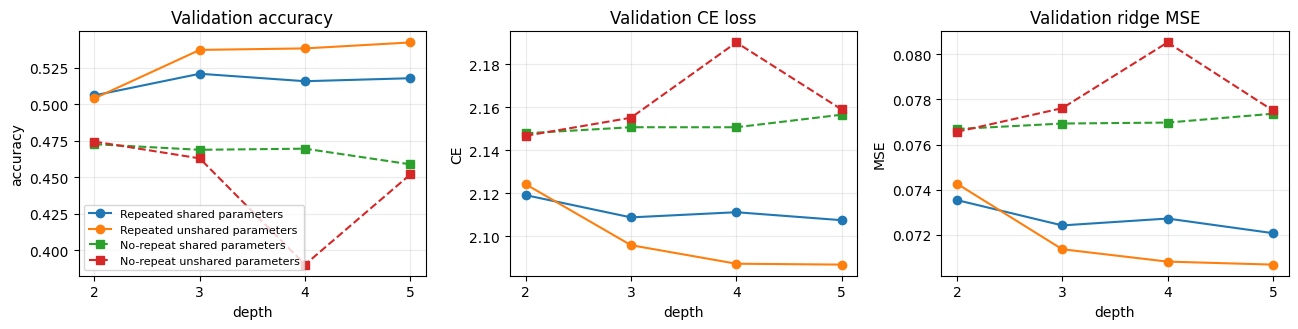

In [4]:
missing_diagnostics = [row["name"] for row in unitary_rows + no_repeat_rows if "val_loss" not in row or "val_ce_loss" not in row]
if missing_diagnostics:
    raise RuntimeError(
        "Imagenette rows do not include validation loss. "
        "Run the benchmark cell again so it regenerates the cache."
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True)
plot_groups = [
    (unitary_rows, "Repeated", "o", "-"),
    (no_repeat_rows, "No-repeat", "s", "--"),
]
for rows_for_group, group_label, marker, linestyle in plot_groups:
    for sharing, sharing_label in sharing_labels.items():
        sharing_rows = sorted(
            [row for row in rows_for_group if row.get("unitary_sharing") == sharing],
            key=lambda row: row["layers"],
        )
        depths = [row["layers"] for row in sharing_rows]
        label = f"{group_label} {sharing_label.lower()}"
        axes[0].plot(depths, [row["val_accuracy"] for row in sharing_rows], marker=marker, linestyle=linestyle, label=label)
        axes[1].plot(depths, [row["val_ce_loss"] for row in sharing_rows], marker=marker, linestyle=linestyle, label=label)
        axes[2].plot(depths, [row["val_loss"] for row in sharing_rows], marker=marker, linestyle=linestyle, label=label)

axes[0].set_title("Validation accuracy")
axes[0].set_ylabel("accuracy")
axes[1].set_title("Validation CE loss")
axes[1].set_ylabel("CE")
axes[2].set_title("Validation ridge MSE")
axes[2].set_ylabel("MSE")
all_depths = sorted({row["layers"] for row in unitary_rows + no_repeat_rows})
for ax in axes:
    ax.set_xlabel("depth")
    ax.set_xticks(all_depths)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Imagenette Validation Confusion Matrices


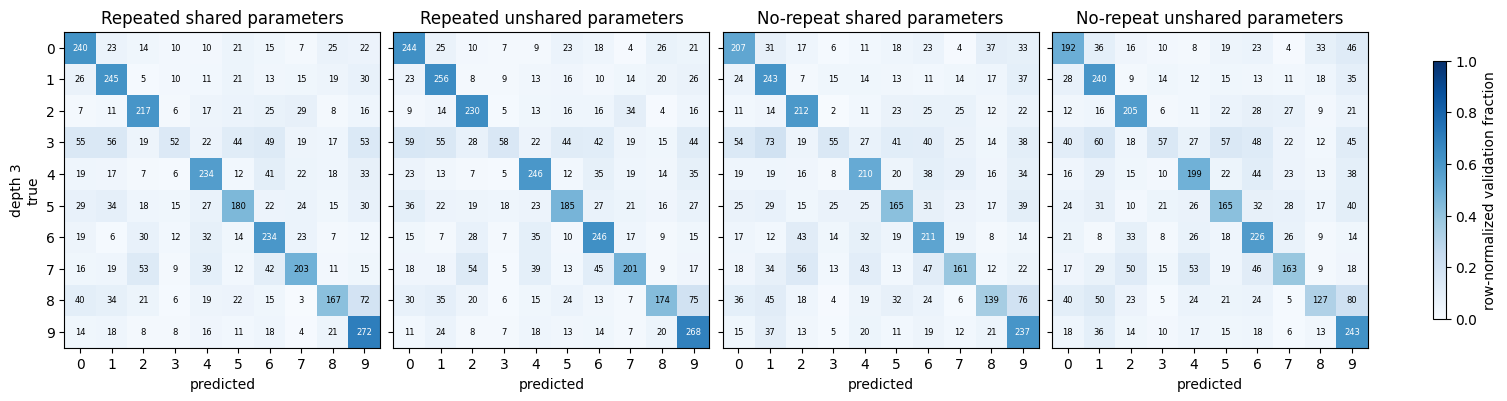

In [5]:
confusion_rows = unitary_rows + no_repeat_rows
missing_confusion = [row["name"] for row in confusion_rows if "val_confusion_matrix" not in row]
if missing_confusion:
    raise RuntimeError(
        "Imagenette rows do not include validation confusion matrices. "
        "Run the benchmark cell again so it regenerates the cache."
    )

target_depth = 3
confusion_cases = [
    (unitary_rows, "tied", "Repeated shared parameters"),
    (unitary_rows, "untied", "Repeated unshared parameters"),
    (no_repeat_rows, "tied", "No-repeat shared parameters"),
    (no_repeat_rows, "untied", "No-repeat unshared parameters"),
]

fig, axes = plt.subplots(
    1,
    len(confusion_cases),
    figsize=(15, 3.8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes).reshape(len(confusion_cases))

image = None
for ax, (rows_for_group, sharing, title) in zip(axes, confusion_cases):
    row = next(row for row in rows_for_group if row["unitary_sharing"] == sharing and row["layers"] == target_depth)
    counts = np.asarray(row["val_confusion_matrix"], dtype=np.int32)
    totals = counts.sum(axis=1, keepdims=True)
    normalized = np.divide(counts, totals, out=np.zeros_like(counts, dtype=np.float32), where=totals != 0)
    image = ax.imshow(normalized, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    for true_label in range(NUM_CLASSES):
        for predicted_label in range(NUM_CLASSES):
            value = int(counts[true_label, predicted_label])
            text_color = "white" if normalized[true_label, predicted_label] > 0.5 else "black"
            ax.text(predicted_label, true_label, value, ha="center", va="center", fontsize=6, color=text_color)

axes[0].set_ylabel(f"depth {target_depth}\ntrue")
fig.colorbar(image, ax=axes, shrink=0.75, label="row-normalized validation fraction")
plt.show()


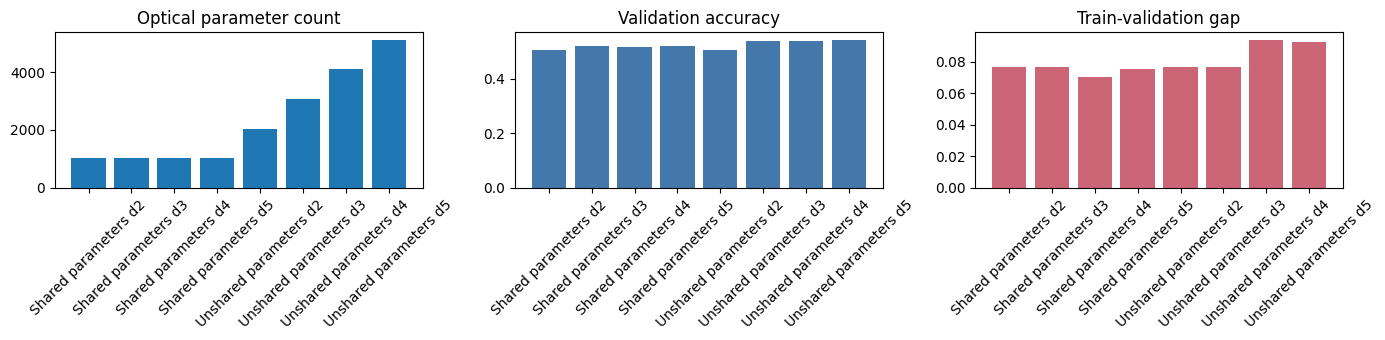

In [6]:
if unitary_rows:
    names = [f"{sharing_labels.get(row["unitary_sharing"], row["unitary_sharing"])} d{row["layers"]}" for row in unitary_rows]
    params = [row.get("learnable_optical_param_count", row.get("stored_optical_param_count", 0)) for row in unitary_rows]
    val_acc = [row.get("val_accuracy", np.nan) for row in unitary_rows]
    train_acc = [row.get("train_accuracy", np.nan) for row in unitary_rows]
    gap = [tr - va for tr, va in zip(train_acc, val_acc)]

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    axes[0].bar(names, params)
    axes[0].set_title("Optical parameter count")
    axes[1].bar(names, val_acc, color="#4477aa")
    axes[1].set_title("Validation accuracy")
    axes[2].bar(names, gap, color="#cc6677")
    axes[2].set_title("Train-validation gap")
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No shared/unshared parameter Imagenette rows found in metrics.json")


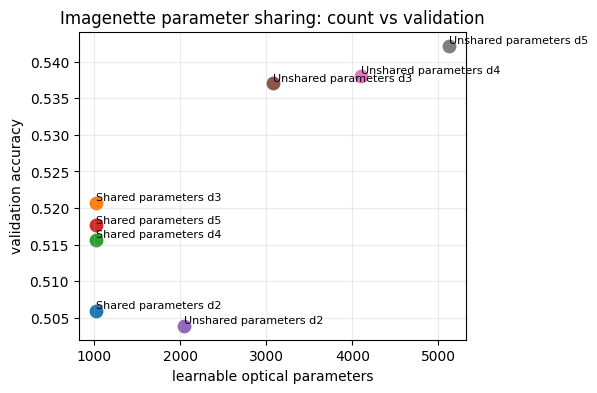

In [7]:
if unitary_rows:
    plt.figure(figsize=(5, 4))
    for row in unitary_rows:
        label = f"{sharing_labels.get(row["unitary_sharing"], row["unitary_sharing"])} d{row["layers"]}"
        x = row.get("learnable_optical_param_count", row.get("stored_optical_param_count", 0))
        y = row.get("val_accuracy", np.nan)
        plt.scatter(x, y, s=80)
        plt.text(x, y, label, fontsize=8, ha="left", va="bottom")
    plt.xlabel("learnable optical parameters")
    plt.ylabel("validation accuracy")
    plt.title("Imagenette parameter sharing: count vs validation")
    plt.grid(alpha=0.25)
    plt.show()


## Interpretation Pattern

When tied and untied models have similar validation accuracy, the tied model can be preferable because it programs fewer optical elements. If the untied model has higher training accuracy but not higher validation accuracy, sharing is acting like a regularizer.

For integrated photonics, fewer independent matrices can mean fewer programmed phase shifters, simpler calibration, and lower control overhead.


## Exercise

From the plotted rows, identify whether the tied model saves parameters without losing validation accuracy. Then inspect the train-validation gap to decide whether the untied model is overfitting.
